In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,3.170909,215.788168,712


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_181720,3.170909,215.788168,712


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_181720,0,6.518501,225.411745,91
1,20260712_181720,1,26.825501,201.717992,67
2,20260712_181720,2,18.987879,225.468176,68
3,20260712_181720,3,20.869673,184.241122,55
4,20260712_181720,4,5.416751,228.525771,77


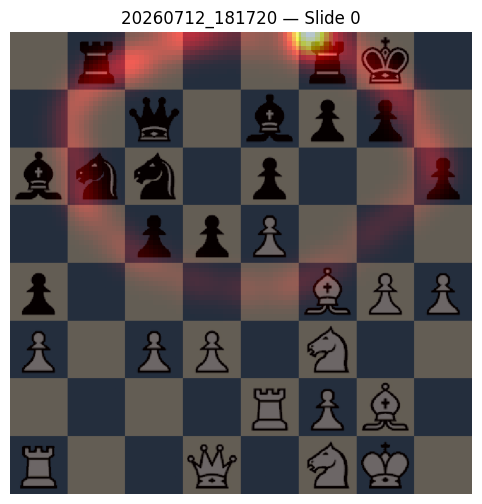

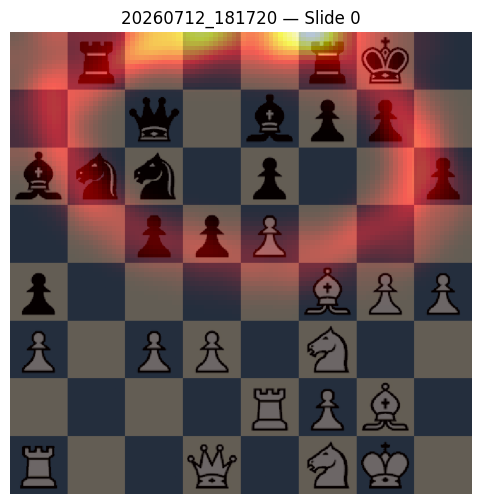

In [3]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,3.170909,215.788168,712


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_181720,3.170909,215.788168,712


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_181720,0,6.518501,225.411745,91
1,20260712_181720,1,26.825501,201.717992,67
2,20260712_181720,2,18.987879,225.468176,68
3,20260712_181720,3,20.869673,184.241122,55
4,20260712_181720,4,5.416751,228.525771,77


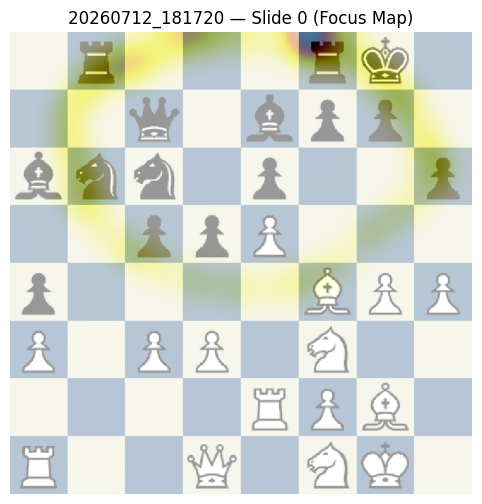

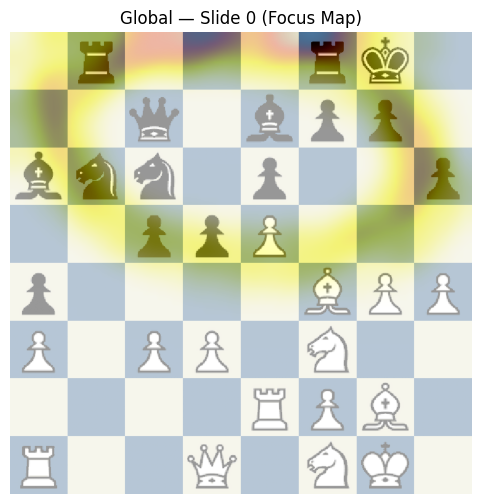

In [4]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260712_181720,0,19.561848,21.192394,1.651217,114.808594,343.570312,106.078125,362.738281,21.062576,2388.816249,976.746110,18774.421400
1,20260712_181720,1,24.813756,26.515827,1.722730,299.484375,349.824219,99.121094,374.199219,201.840494,2767.080000,1036.315329,23106.364378
2,20260712_181720,2,30.553768,31.864522,1.321122,170.296875,349.093750,157.457031,371.394531,25.732983,6799.595788,1189.358722,32854.622034
3,20260712_181720,3,37.106900,38.404226,1.318094,-258.871094,371.824219,130.253906,368.011719,389.143676,3776.553534,1311.201983,36340.919205
4,20260712_181720,3,38.435382,38.456060,0.041493,127.628906,364.296875,125.347656,360.355469,4.553986,143.922532,109.658284,8766.799259


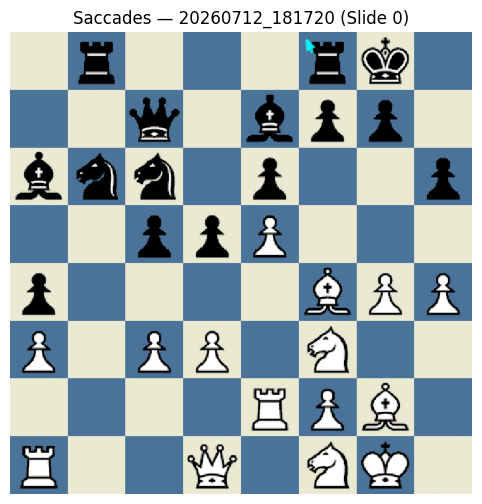

In [5]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,19.634230,19.716707,0.082476,-86.654687,360.707812,61.972656,20260712_181720,0
1,19.737357,19.819877,0.082520,-150.399219,335.609375,65.226562,20260712_181720,0
2,19.840519,19.964340,0.123822,-201.464286,316.228795,72.929688,20260712_181720,0
3,20.077856,20.160319,0.082462,-274.933594,202.149219,73.160156,20260712_181720,0
4,20.180923,20.263296,0.082373,-260.342188,124.532031,60.035156,20260712_181720,0


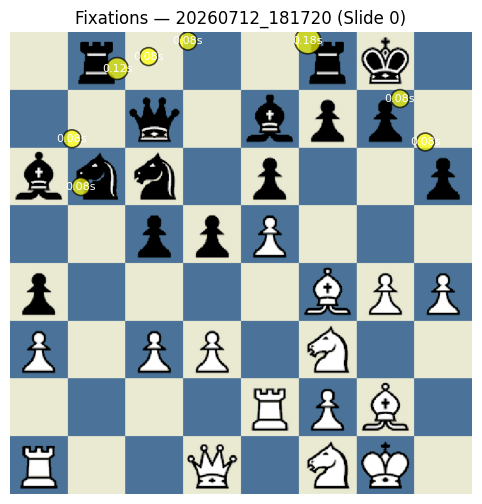

In [6]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260712_181720,0,output/20260712_181720/frame_37_delay-1s.gif,datasets/chess/good/frame_37_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,136.339844,340.203125,None,None,5,0,136.339844,340.203125,2.5,0
1,20260712_181720,0,output/20260712_181720/frame_37_delay-1s.gif,datasets/chess/good/frame_37_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,114.808594,343.570312,None,None,5,0,114.808594,343.570312,2.5,0
2,20260712_181720,0,output/20260712_181720/frame_37_delay-1s.gif,datasets/chess/good/frame_37_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,74.109375,351.851562,None,None,5,0,74.109375,351.851562,2.5,0
3,20260712_181720,0,output/20260712_181720/frame_37_delay-1s.gif,datasets/chess/good/frame_37_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,25.015625,357.468750,None,None,5,0,25.015625,357.468750,2.5,0
4,20260712_181720,0,output/20260712_181720/frame_37_delay-1s.gif,datasets/chess/good/frame_37_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-4.917969,360.953125,None,None,5,0,-4.917969,360.953125,2.5,0


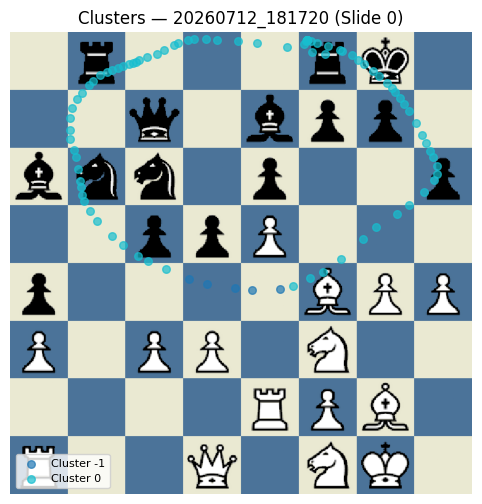

In [7]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,6.291844,184015.480652,91,20260712_181720,0
1,6.066089,185554.972832,67,20260712_181720,1
2,6.087463,157722.774750,68,20260712_181720,2
3,5.708632,219883.485222,55,20260712_181720,3
4,6.240813,155806.937874,77,20260712_181720,4


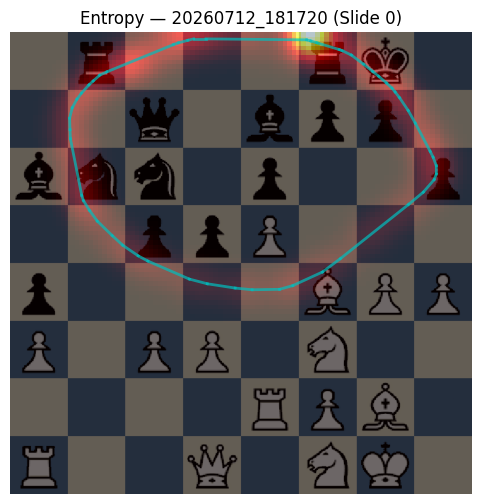

In [8]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
